# Mesoscale removal from GLORYS12 with the implicit filter: method and what is removed
**GLORYS12v1 (NEMO ORCA12 C-grid), January 1993, Amazon plume / North Brazil Current region.**

This notebook shows **how** the filter works and **what it removes**. It reads the finished filtered fields in `../implicit_run/output/`, so it runs on a normal CPU Jupyter node (kernel `implicit_filter`) in a few minutes. The interactive filtering itself, on the GPU, is in `v0.Implicit_filtering_ARP.ipynb`. The full analysis is in `../implicit_run/REPORT.md`.

Contents
1. The method in one page
2. The five filter configurations, and what **R2Ld** and **R3Ld** are
3. Which wavelengths each filter keeps (transfer functions)
4. One day at the surface: original, filtered, and the **removed mesoscale** (speed and vorticity)
5. The removed field for every configuration, side by side
6. Eddy kinetic energy: kept and removed
7. Spectra: the energy removed as a function of wavelength
8. NBC rings in time: Hovmöller at 8°N
9. The NBC at 44°W: original, filtered, removed
10. Summary and recommendation

## 1. The method in one page

**Implicit filter** (Danilov et al. 2023, *JAMES*; Nowak et al. 2025, *GMD*). Instead of convolving with a kernel, the filtered field $\overline{\phi}$ is the solution of an elliptic equation on the model grid:

$$\left(1 + \tfrac12\,\ell^2\,(-\Delta)\right)\overline{\phi} = \phi \qquad (\gamma=\tfrac12,\ n=1).$$

- **One sparse linear solve** per field. It runs on the native grid, respects coastlines (no-flux at land) and needs no interpolation.
- **Transfer function.** A wave of wavelength λ (wavenumber $K=2\pi/\lambda$) is multiplied by
$$G(\lambda) = \frac{1}{1 + \tfrac12\,\ell^2 (2\pi/\lambda)^2}.$$
  Long waves ($\lambda \gg 2\pi\ell$) pass, short waves are damped, with no ringing or negative side lobes.
- **Scale.** A box (running-mean) filter of width $L$ removes about the same as $\ell = L/3.5$ (matching second moments). A "2° window" therefore means $L = 2°\times111\,\mathrm{km}\times\cos\varphi \approx 222$ km at the equator, so $\ell \approx 63$ km.
- **Mesoscale removed** = original − filtered = $(1-G)\,\phi$.

**Applied to GLORYS12 (C-grid)**
- **U, V:** filtered **together as a vector** on their own U and V points, level by level, with NEMO's discrete divergence and vorticity (zero flow through coasts, free slip). For constant ℓ this is the same as filtering U and V separately. Filtering them separately with separate coastal walls created false convergence along every coast.
- **W:** the rigid-lid W from `data/Fix_W.ipynb`, filtered as a scalar at the same ℓ, with the operator that matches the U,V filter. It is **not** recomputed from divergence.
- **Check:** in open water the filtered U, V, W satisfy continuity as well as the original fields do.

In [1]:
import sys, json, os
import numpy as np
import netCDF4
import matplotlib.pyplot as plt
import matplotlib as mpl

RUN = '/work/bk1450/b383184/Amazon/Mercator/implicit_run'
IN = '/work/bk1450/b383184/Amazon/Mercator/implicit_data/'
Hgr = '/work/bk1450/b383184/Amazon/Mercator/data/Hgr_cmesh.nc'
Zgr = '/work/bk1450/b383184/Amazon/Mercator/data/Zgr_cmesh2.nc'
sys.path.insert(0, RUN)
import cgrid_filter as cf

CFGS = ['W1.5', 'W2.0', 'W2.5', 'R2Ld', 'R3Ld']
LABEL = {'ORIG': 'GLORYS12 original', 'W1.5': 'W1.5 (1.5° window)', 'W2.0': 'W2.0 (2.0° window)',
         'W2.5': 'W2.5 (2.5° window)', 'R2Ld': 'R2Ld (2 × Rossby radius)', 'R3Ld': 'R3Ld (3 × Rossby radius)'}
COL = {'ORIG': 'k', 'W1.5': '#1b9e77', 'W2.0': '#d95f02', 'W2.5': '#7570b3', 'R2Ld': '#e7298a', 'R3Ld': '#66a61e'}
plt.rcParams.update({'figure.dpi': 90, 'font.size': 10})

mesh = cf.CMesh(hgr=Hgr, zgr=Zgr)
lon, lat = mesh.glamt, mesh.gphit

def box(lon0, lon1, lat0, lat1):
    j = np.where((lat[:, 600] >= lat0) & (lat[:, 600] <= lat1))[0]
    i = np.where((lon[200] >= lon0) & (lon[200] <= lon1))[0]
    return slice(j.min(), j.max() + 1), slice(i.min(), i.max() + 1)

JS, IS = box(-70, -30, -5, 30)          # analysis domain
land = ~mesh.tmask[0][JS, IS]

def path(var, cfg):
    return IN + f'{var}_1993-01c.nc' if cfg == 'ORIG' else f'{RUN}/output/{cfg}/{var}_1993-01c_{cfg}.nc'

def read_uv(cfg, k=0, t=slice(None), js=JS, is_=IS):
    u = netCDF4.Dataset(path('U', cfg))['vozocrtx'][t, k, js, is_].filled(np.nan).astype(np.float64)
    v = netCDF4.Dataset(path('V', cfg))['vomecrty'][t, k, js, is_].filled(np.nan).astype(np.float64)
    return u, v

def to_T(u, v):
    """C-grid u, v (..., y, x) -> T points (average of the two faces; land faces = 0)."""
    u0, v0 = np.nan_to_num(u), np.nan_to_num(v)
    ut = np.zeros_like(u0); vt = np.zeros_like(v0)
    ut[..., 1:] = 0.5 * (u0[..., 1:] + u0[..., :-1]); vt[..., 1:, :] = 0.5 * (v0[..., 1:, :] + v0[..., :-1, :])
    return ut, vt

e1u, e2v, e1f, e2f = (mesh.e1u[JS, IS], mesh.e2v[JS, IS], mesh.e1f[JS, IS], mesh.e2f[JS, IS])
def vorticity(u, v):
    """Relative vorticity at F points [1/s] (NEMO form), returned on the same array shape."""
    u0, v0 = np.nan_to_num(u), np.nan_to_num(v)
    z = np.full(u0.shape, np.nan)
    z[..., :-1, :-1] = ((v0[..., :-1, 1:] * e2v[:-1, 1:] - v0[..., :-1, :-1] * e2v[:-1, :-1])
                        - (u0[..., 1:, :-1] * e1u[1:, :-1] - u0[..., :-1, :-1] * e1u[:-1, :-1])) / (e1f[:-1, :-1] * e2f[:-1, :-1])
    return z

def mapax(ax, title):
    ax.set_title(title, fontsize=10); ax.set_xlim(-70, -30); ax.set_ylim(-5, 30)
    ax.contourf(lon[JS, IS], lat[JS, IS], land, levels=[0.5, 1.5], colors='0.75')
print('grid', mesh.ny, mesh.nx, ' analysis box', lon[JS, IS].shape)

grid 499 1260  analysis box (438, 481)


## 2. The five filter configurations, and what R2Ld and R3Ld are

| Name | Filter scale | Meaning |
|---|---|---|
| **W1.5, W2.0, W2.5** | $\ell = \Delta\theta\cdot\frac{\pi}{180}R\cos\varphi\,/\,3.5$ with $\Delta\theta$ = 1.5°, 2.0°, 2.5° | A **fixed angular window**: the filter behaves like a running mean over a 1.5°, 2.0° or 2.5° box. In km it shrinks slightly with latitude, like the grid (×cos φ). |
| **R2Ld** | $\ell = 2\,L_d/3.5$ | A **Rossby-radius window**. The box width is **2 × the first-baroclinic Rossby deformation radius** $L_d$ at each grid point. |
| **R3Ld** | $\ell = 3\,L_d/3.5$ | Same, with a box width of **3 × $L_d$**. |

**What is $L_d$?** $L_d$ is the natural size of ocean eddies at each place. It is computed from the GLORYS January-1993 temperature and salinity (folder `implicit_run/rossby/`):
- the first baroclinic gravity-wave speed is $c_1 = \frac{1}{\pi}\int N\,dz$, with $N$ the buoyancy frequency;
- then $L_d = c_1/|f|$ away from the equator, and $L_d=\sqrt{c_1/2\beta}$ near it (Chelton et al. 1998).

The idea of R2Ld/R3Ld is to adapt the filter to the local eddy size, because eddy diameters are typically 2–4 $L_d$. In this domain $L_d$ varies 7-fold, from ~240 km at the equator to ~33 km at 30°N. So the Rossby filters are **much wider than the windows near the equator** and **much narrower in the subtropics**.

W1.5: box width at 0° / 10°N / 20°N / 30°N =  167 /  164 /  157 /  145 km
W2.0: box width at 0° / 10°N / 20°N / 30°N =  222 /  219 /  209 /  194 km
W2.5: box width at 0° / 10°N / 20°N / 30°N =  278 /  274 /  261 /  242 km
R2Ld: box width at 0° / 10°N / 20°N / 30°N =  475 /  212 /  105 /   67 km
R3Ld: box width at 0° / 10°N / 20°N / 30°N =  712 /  318 /  157 /  100 km


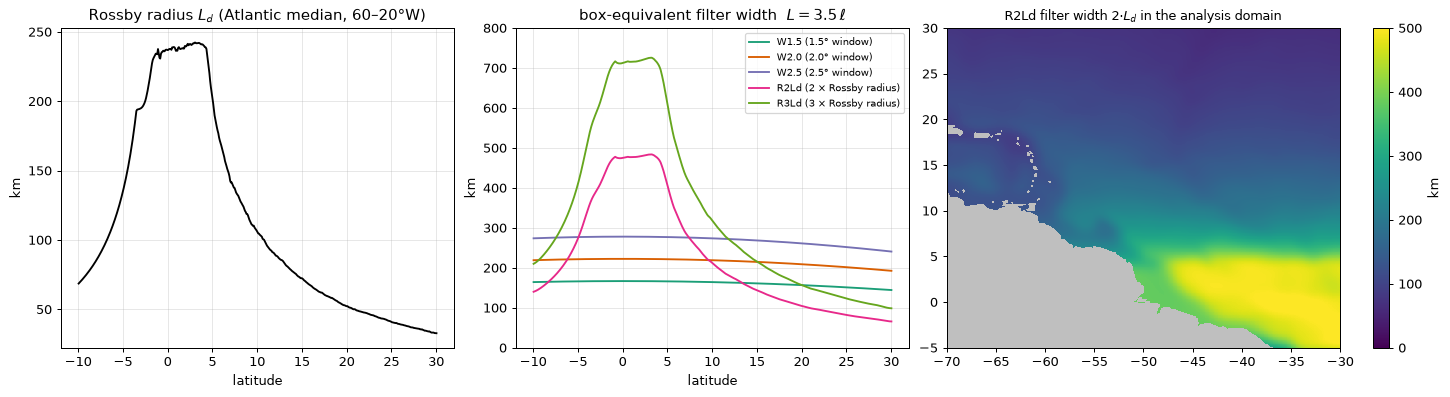

In [2]:
ld = netCDF4.Dataset(RUN + '/rossby/rossby_radius_T.nc')['Ld'][:].astype(float)
ells = {'W1.5': cf.ell_T_F(mesh, 'window', window_deg=1.5)[0], 'W2.0': cf.ell_T_F(mesh, 'window', window_deg=2.0)[0],
        'W2.5': cf.ell_T_F(mesh, 'window', window_deg=2.5)[0],
        'R2Ld': cf.ell_T_F(mesh, 'rossby', ld_T=ld, mult=2.0)[0], 'R3Ld': cf.ell_T_F(mesh, 'rossby', ld_T=ld, mult=3.0)[0]}
atl = box(-60, -20, -10, 31)[1]
latc = lat[:, 700]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3), constrained_layout=True)
ax[0].plot(latc, np.nanmedian(ld[:, atl], 1) / 1e3, 'k'); ax[0].set_title('Rossby radius $L_d$ (Atlantic median, 60–20°W)')
ax[0].set_xlabel('latitude'); ax[0].set_ylabel('km'); ax[0].grid(alpha=.3)
for c in CFGS:
    ax[1].plot(latc, 3.5 * np.median(ells[c][:, atl], 1) / 1e3, color=COL[c], label=LABEL[c])
ax[1].set_title('box-equivalent filter width  $L = 3.5\\,\\ell$'); ax[1].set_xlabel('latitude'); ax[1].set_ylabel('km')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3); ax[1].set_ylim(0, 800)
pc = ax[2].pcolormesh(lon[JS, IS], lat[JS, IS], np.ma.masked_array(3.5 * ells['R2Ld'][JS, IS] / 1e3, land), cmap='viridis', vmin=0, vmax=500)
fig.colorbar(pc, ax=ax[2], label='km'); mapax(ax[2], 'R2Ld filter width 2·$L_d$ in the analysis domain')
for c in CFGS:
    e = ells[c][:, atl]
    print(f"{c}: box width at 0° / 10°N / 20°N / 30°N = " +
          ' / '.join(f"{3.5*np.median(e[np.argmin(abs(latc-L))])/1e3:4.0f}" for L in (0, 10, 20, 29.5)) + ' km')

## 3. Which wavelengths each filter keeps

The fraction of a wave's **energy** that survives is $G^2$. The fraction removed is $1-G^2$. The plot shows $G^2$ against wavelength at four latitudes.

The mesoscale in the tropical Atlantic has eddy diameters of ~50–450 km, i.e. wavelengths of ~100–900 km. The widest are the NBC rings (300–450 km diameter).

Text(0.5, 0.98, 'Energy transfer function of each filter (theory, verified on the grid to <1 %)')

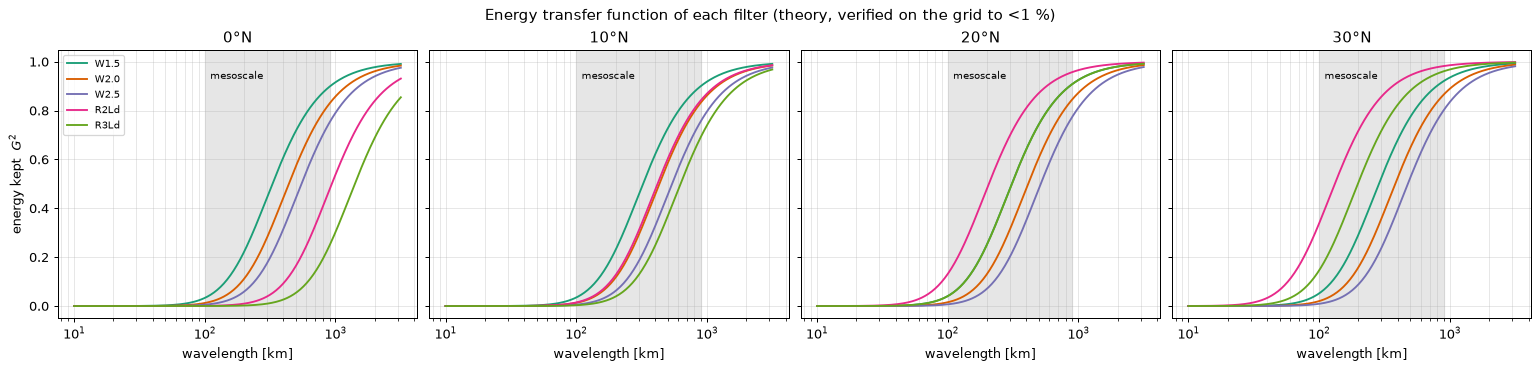

In [3]:
lamkm = np.logspace(1, 3.5, 300)
fig, ax = plt.subplots(1, 4, figsize=(17, 4), sharey=True, constrained_layout=True)
for a, L in zip(ax, (0, 10, 20, 29.5)):
    jl = np.argmin(abs(latc - L))
    for c in CFGS:
        l = np.median(ells[c][jl, atl])
        G = 1 / (1 + 0.5 * l**2 * (2 * np.pi / (lamkm * 1e3))**2)
        a.semilogx(lamkm, G**2, color=COL[c], label=c)
    a.axvspan(100, 900, color='0.9', zorder=0); a.text(110, 0.93, 'mesoscale', fontsize=8)
    a.set_title(f'{L:.0f}°N'); a.set_xlabel('wavelength [km]'); a.grid(alpha=.3, which='both')
ax[0].set_ylabel('energy kept  $G^2$'); ax[0].legend(fontsize=8)
fig.suptitle('Energy transfer function of each filter (theory, verified on the grid to <1 %)')

## 4. One day at the surface: original, filtered, and the removed mesoscale

Shown for 11 January 1993 and **W2.0**:
- **Top row, speed:** the removed part is $|\mathbf u - \overline{\mathbf u}|$.
- **Bottom row, relative vorticity ζ:** eddies stand out most clearly in vorticity. The removed vorticity is the eddy and filament field that the filter takes out.

Text(0.5, 0.98, '11 January 1993, surface: what W2.0 keeps and what it removes')

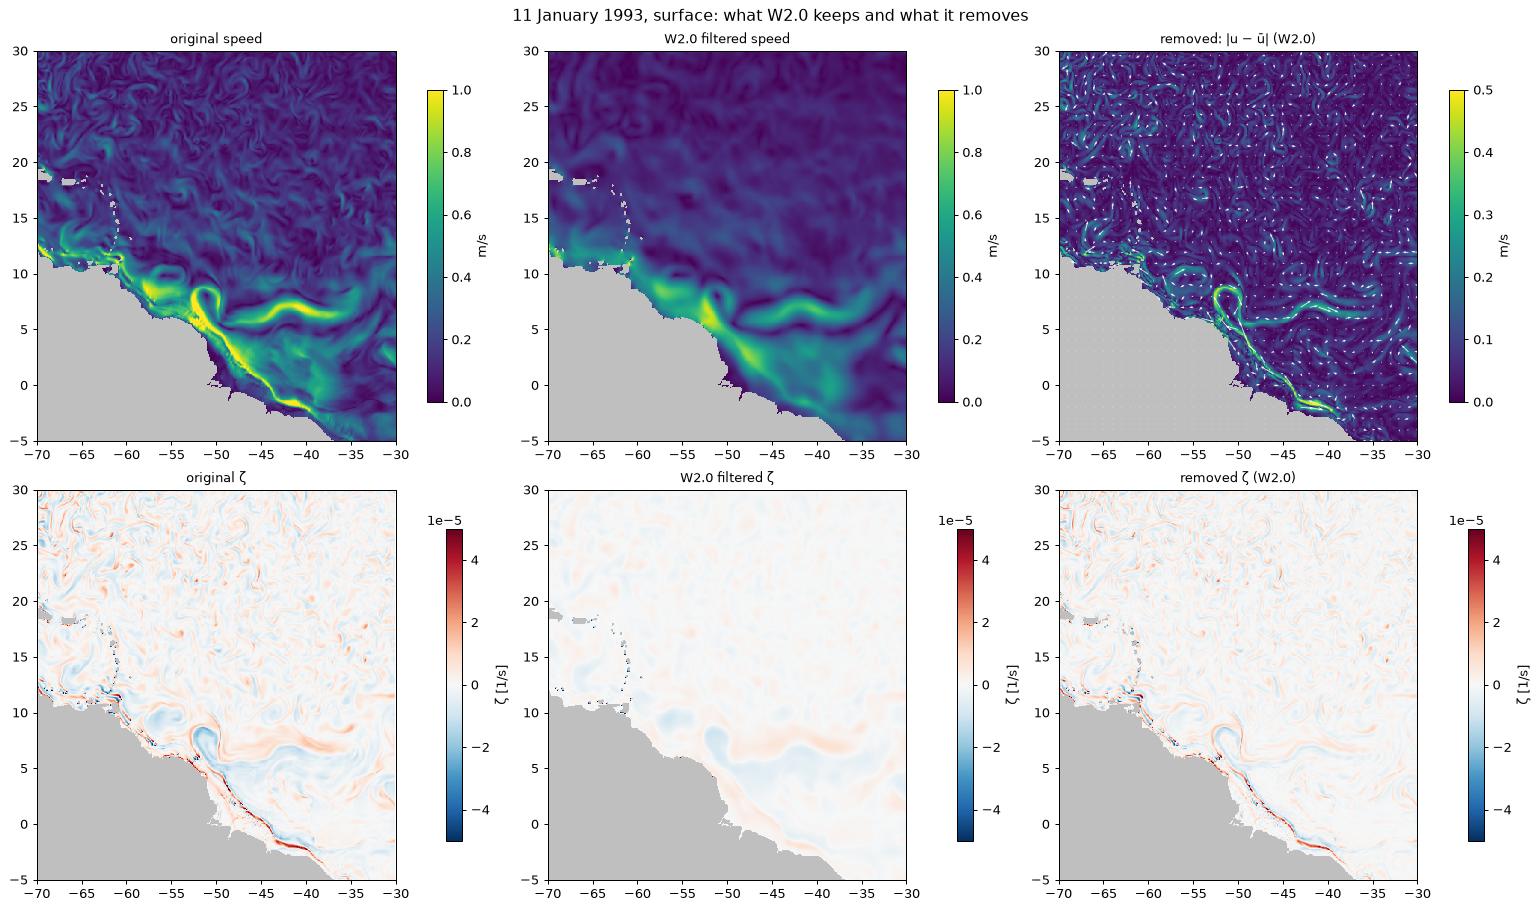

In [4]:
t = 10
U, V = {}, {}
for c in ['ORIG'] + CFGS:
    U[c], V[c] = read_uv(c, k=0, t=t)
sp = lambda u, v: np.ma.masked_array(np.hypot(*to_T(u, v)), land)
cfg = 'W2.0'
du, dv = U['ORIG'] - U[cfg], V['ORIG'] - V[cfg]
fig, ax = plt.subplots(2, 3, figsize=(17, 10), constrained_layout=True)
for a, (fld, ttl) in zip(ax[0], [(sp(U['ORIG'], V['ORIG']), 'original speed'), (sp(U[cfg], V[cfg]), f'{cfg} filtered speed'),
                                 (sp(du, dv), f'removed: |u − ū| ({cfg})')]):
    pc = a.pcolormesh(lon[JS, IS], lat[JS, IS], fld, vmin=0, vmax=1.0 if 'removed' not in ttl else 0.5, cmap='viridis'); mapax(a, ttl)
    fig.colorbar(pc, ax=a, shrink=.8, label='m/s')
q = 12
ut, vt = to_T(du, dv)
ax[0, 2].quiver(lon[JS, IS][::q, ::q], lat[JS, IS][::q, ::q], ut[::q, ::q], vt[::q, ::q], scale=8, width=0.002, color='w')
zmax = 5e-5
for a, (u_, v_, ttl) in zip(ax[1], [(U['ORIG'], V['ORIG'], 'original ζ'), (U[cfg], V[cfg], f'{cfg} filtered ζ'), (du, dv, f'removed ζ ({cfg})')]):
    pc = a.pcolormesh(lon[JS, IS], lat[JS, IS], np.ma.masked_array(vorticity(u_, v_), land), vmin=-zmax, vmax=zmax, cmap='RdBu_r'); mapax(a, ttl)
    fig.colorbar(pc, ax=a, shrink=.8, label='ζ [1/s]')
fig.suptitle('11 January 1993, surface: what W2.0 keeps and what it removes', fontsize=13)

## 5. The removed mesoscale for every configuration

**Top row:** speed of the removed flow. **Bottom row:** removed vorticity. Same day and same colour scales.

What to look for:
- **Window filters (W):** they remove eddies of similar size everywhere. More of the retroflection eddies and NBC rings is removed as the window grows.
- **Rossby filters (R):** they remove broad structure near the equator, including part of the NBC and the equatorial currents, but almost nothing in the eddy-rich subtropics north of ~15°N, where $L_d$ is small.

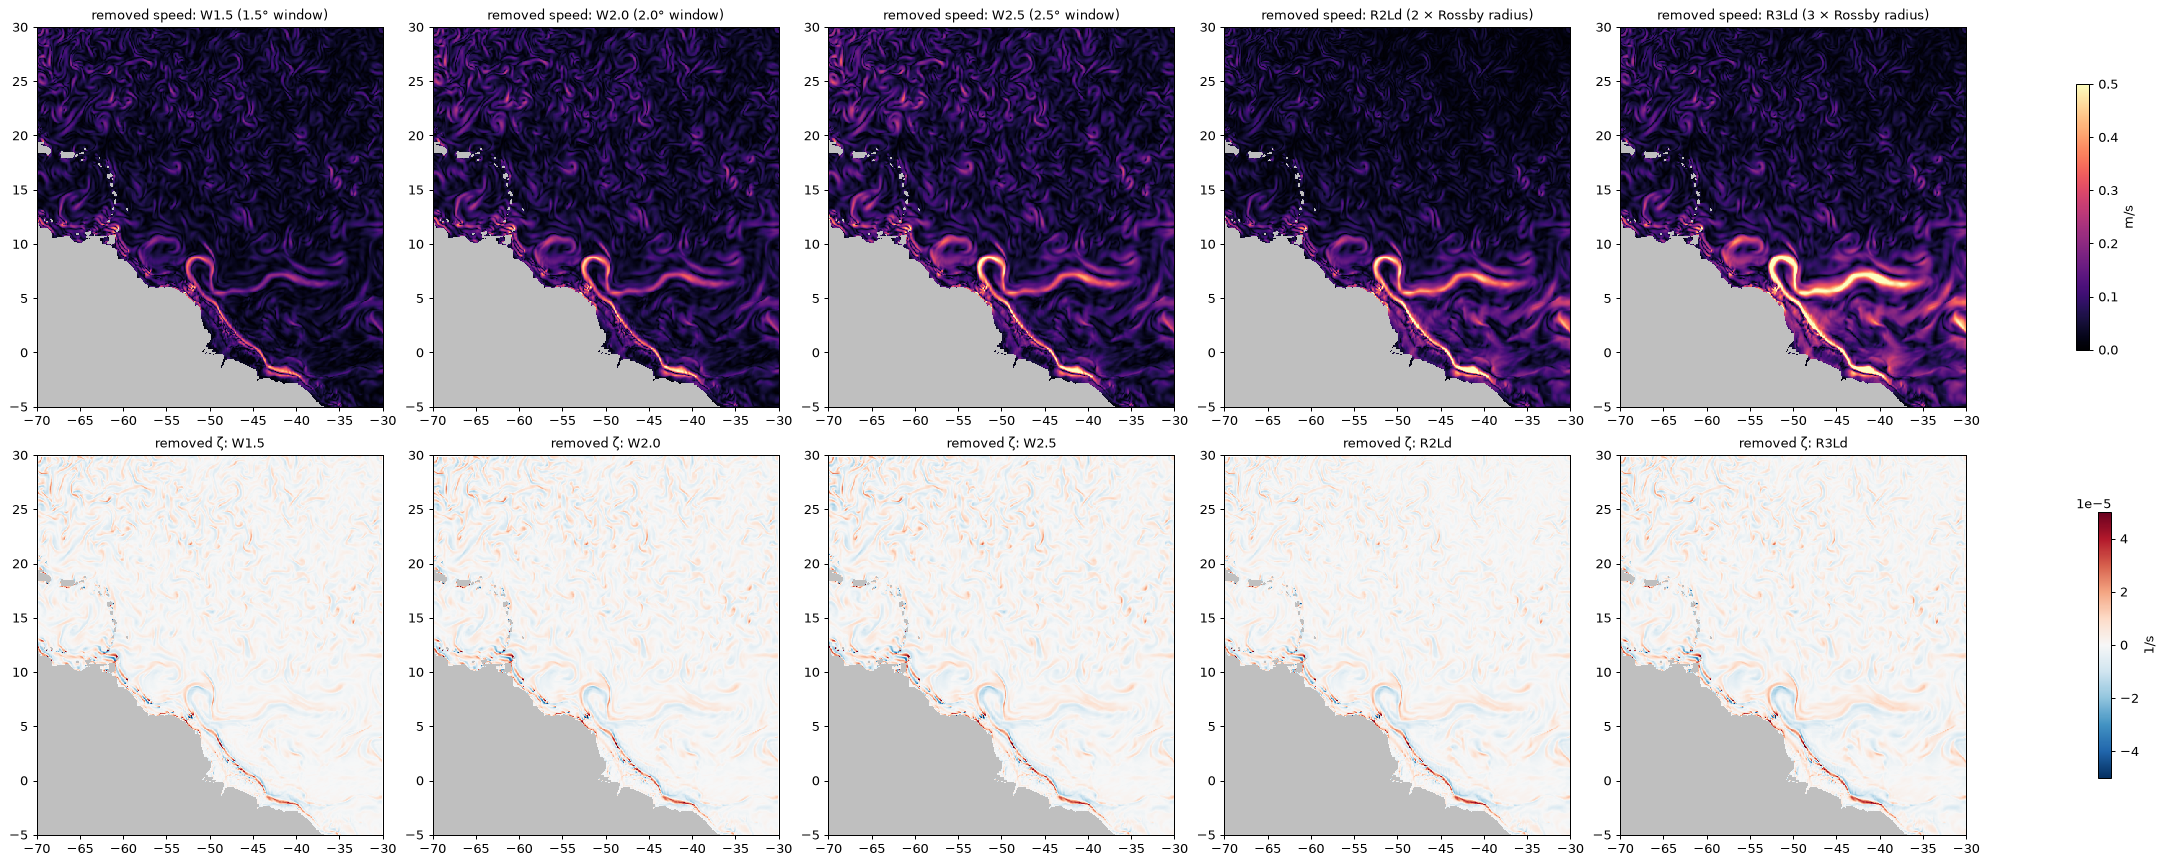

In [5]:
fig, ax = plt.subplots(2, 5, figsize=(24, 9.5), constrained_layout=True)
for n, c in enumerate(CFGS):
    du, dv = U['ORIG'] - U[c], V['ORIG'] - V[c]
    pc1 = ax[0, n].pcolormesh(lon[JS, IS], lat[JS, IS], sp(du, dv), vmin=0, vmax=0.5, cmap='magma'); mapax(ax[0, n], f'removed speed: {LABEL[c]}')
    pc2 = ax[1, n].pcolormesh(lon[JS, IS], lat[JS, IS], np.ma.masked_array(vorticity(du, dv), land), vmin=-5e-5, vmax=5e-5, cmap='RdBu_r')
    mapax(ax[1, n], f'removed ζ: {c}')
fig.colorbar(pc1, ax=ax[0], shrink=.7, label='m/s'); fig.colorbar(pc2, ax=ax[1], shrink=.7, label='1/s')

## 6. Eddy kinetic energy: kept and removed

- **EKE** is the kinetic energy of the day-to-day variability, $\tfrac12\langle (u-\langle u\rangle_t)^2 + (v-\langle v\rangle_t)^2\rangle_t$ over the 31 days.
- The **removed energy** is $\tfrac12\langle |\mathbf u - \overline{\mathbf u}|^2\rangle_t$: all scales the filter takes out, mean and variability.
- The profile shows the energy removed versus depth, area-weighted over the analysis box.

W1.5: surface EKE kept 0.62   EKE removed 0.38
W2.0: surface EKE kept 0.52   EKE removed 0.48
W2.5: surface EKE kept 0.45   EKE removed 0.55
R2Ld: surface EKE kept 0.47   EKE removed 0.53
R3Ld: surface EKE kept 0.32   EKE removed 0.68


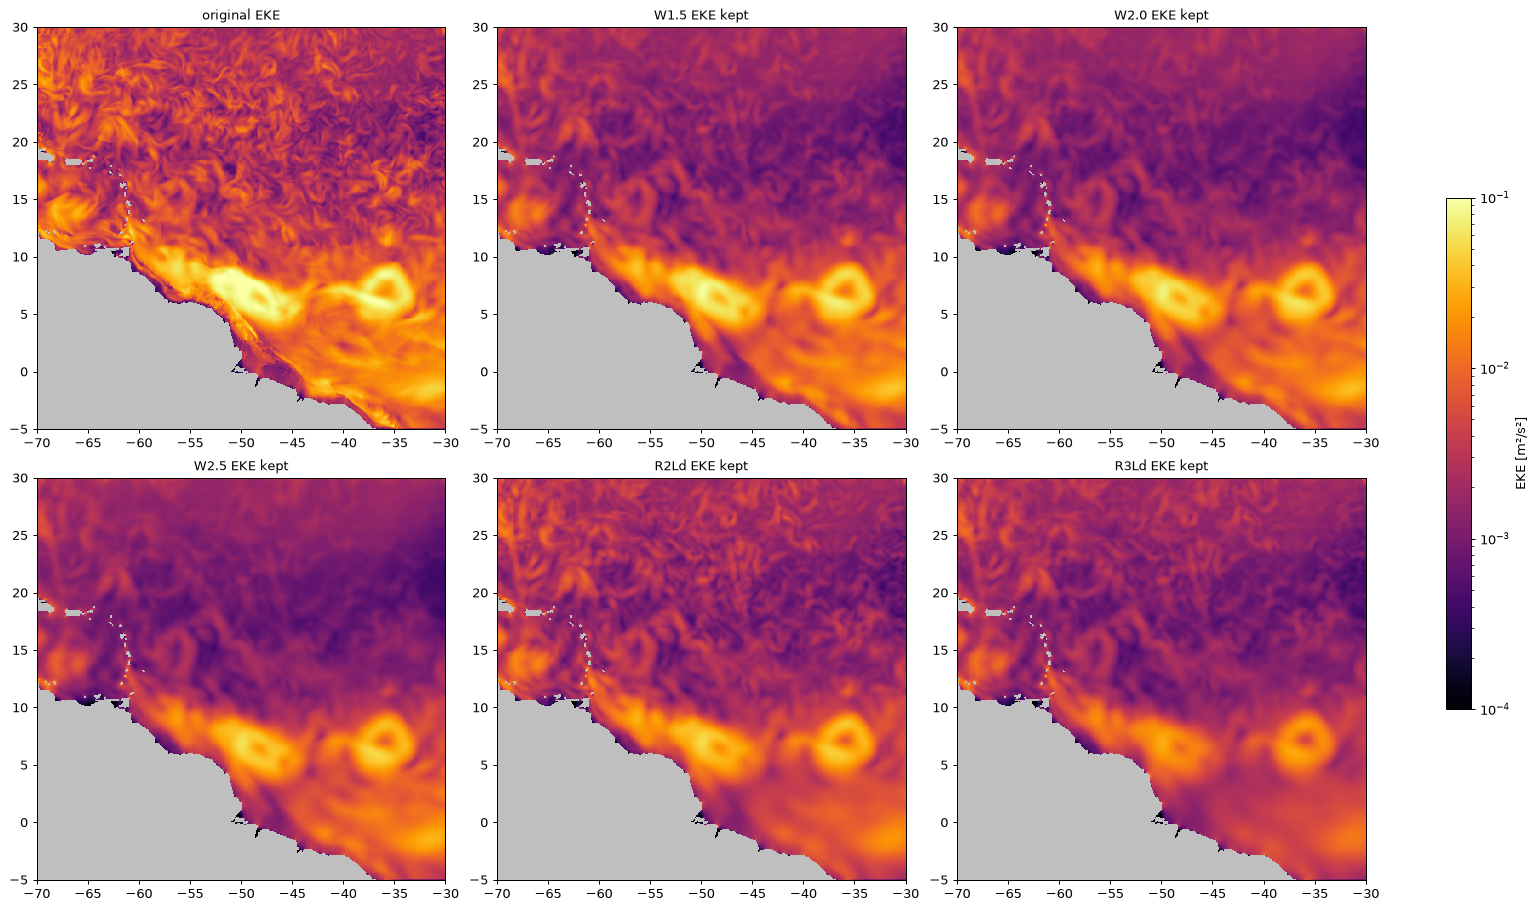

In [6]:
Ua, Va = {}, {}
for c in ['ORIG'] + CFGS:
    Ua[c], Va[c] = to_T(*read_uv(c, k=0))          # 31 days at the surface, T points
def eke(u, v):
    return 0.5 * (np.mean((u - u.mean(0))**2, 0) + np.mean((v - v.mean(0))**2, 0))
EKE = {c: eke(Ua[c], Va[c]) for c in Ua}
REM = {c: 0.5 * np.mean((Ua['ORIG'] - Ua[c])**2 + (Va['ORIG'] - Va[c])**2, 0) for c in CFGS}
w = (mesh.e1t * mesh.e2t)[JS, IS] * ~land
fig, ax = plt.subplots(2, 3, figsize=(17, 10), constrained_layout=True)
norm = mpl.colors.LogNorm(1e-4, 1e-1)
for a, (fld, ttl) in zip(ax.flat, [(EKE['ORIG'], 'original EKE'), (EKE['W1.5'], 'W1.5 EKE kept'), (EKE['W2.0'], 'W2.0 EKE kept'),
                                   (EKE['W2.5'], 'W2.5 EKE kept'), (EKE['R2Ld'], 'R2Ld EKE kept'), (EKE['R3Ld'], 'R3Ld EKE kept')]):
    pc = a.pcolormesh(lon[JS, IS], lat[JS, IS], np.ma.masked_array(fld, land), norm=norm, cmap='inferno'); mapax(a, ttl)
fig.colorbar(pc, ax=ax, shrink=.6, label='EKE [m²/s²]')
for c in CFGS:
    print(f'{c}: surface EKE kept {np.sum(EKE[c]*w)/np.sum(EKE["ORIG"]*w):.2f}   EKE removed {1-np.sum(EKE[c]*w)/np.sum(EKE["ORIG"]*w):.2f}')

Text(0.5, 1.0, 'EKE removed by latitude band (70–30°W)')

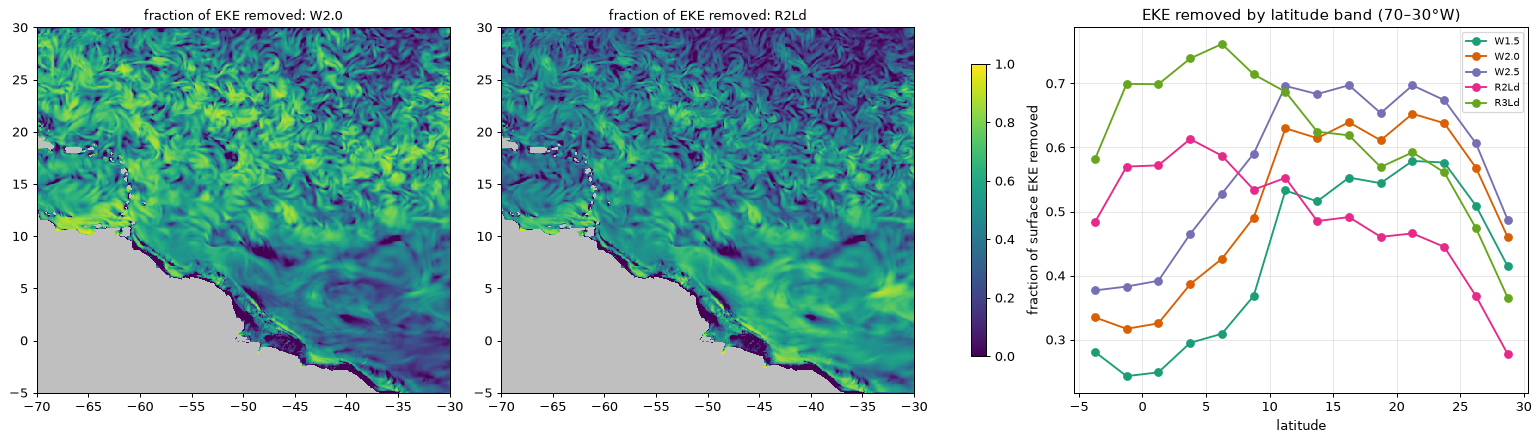

In [7]:
# fraction of surface EKE removed, maps + latitude profile
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8), constrained_layout=True, gridspec_kw={'width_ratios': [1, 1, 1.1]})
for a, c in zip(ax[:2], ['W2.0', 'R2Ld']):
    pc = a.pcolormesh(lon[JS, IS], lat[JS, IS], np.ma.masked_array(1 - EKE[c] / np.maximum(EKE['ORIG'], 1e-8), land), vmin=0, vmax=1, cmap='viridis')
    mapax(a, f'fraction of EKE removed: {c}')
fig.colorbar(pc, ax=ax[:2], shrink=.8)
latb = lat[JS, IS]
for c in CFGS:
    prof = [1 - np.sum((EKE[c]*w)[(latb >= L) & (latb < L + 2.5)]) / np.sum((EKE['ORIG']*w)[(latb >= L) & (latb < L + 2.5)]) for L in np.arange(-5, 30, 2.5)]
    ax[2].plot(np.arange(-5, 30, 2.5) + 1.25, prof, 'o-', color=COL[c], label=c)
ax[2].set_xlabel('latitude'); ax[2].set_ylabel('fraction of surface EKE removed'); ax[2].grid(alpha=.3); ax[2].legend(fontsize=8)
ax[2].set_title('EKE removed by latitude band (70–30°W)')

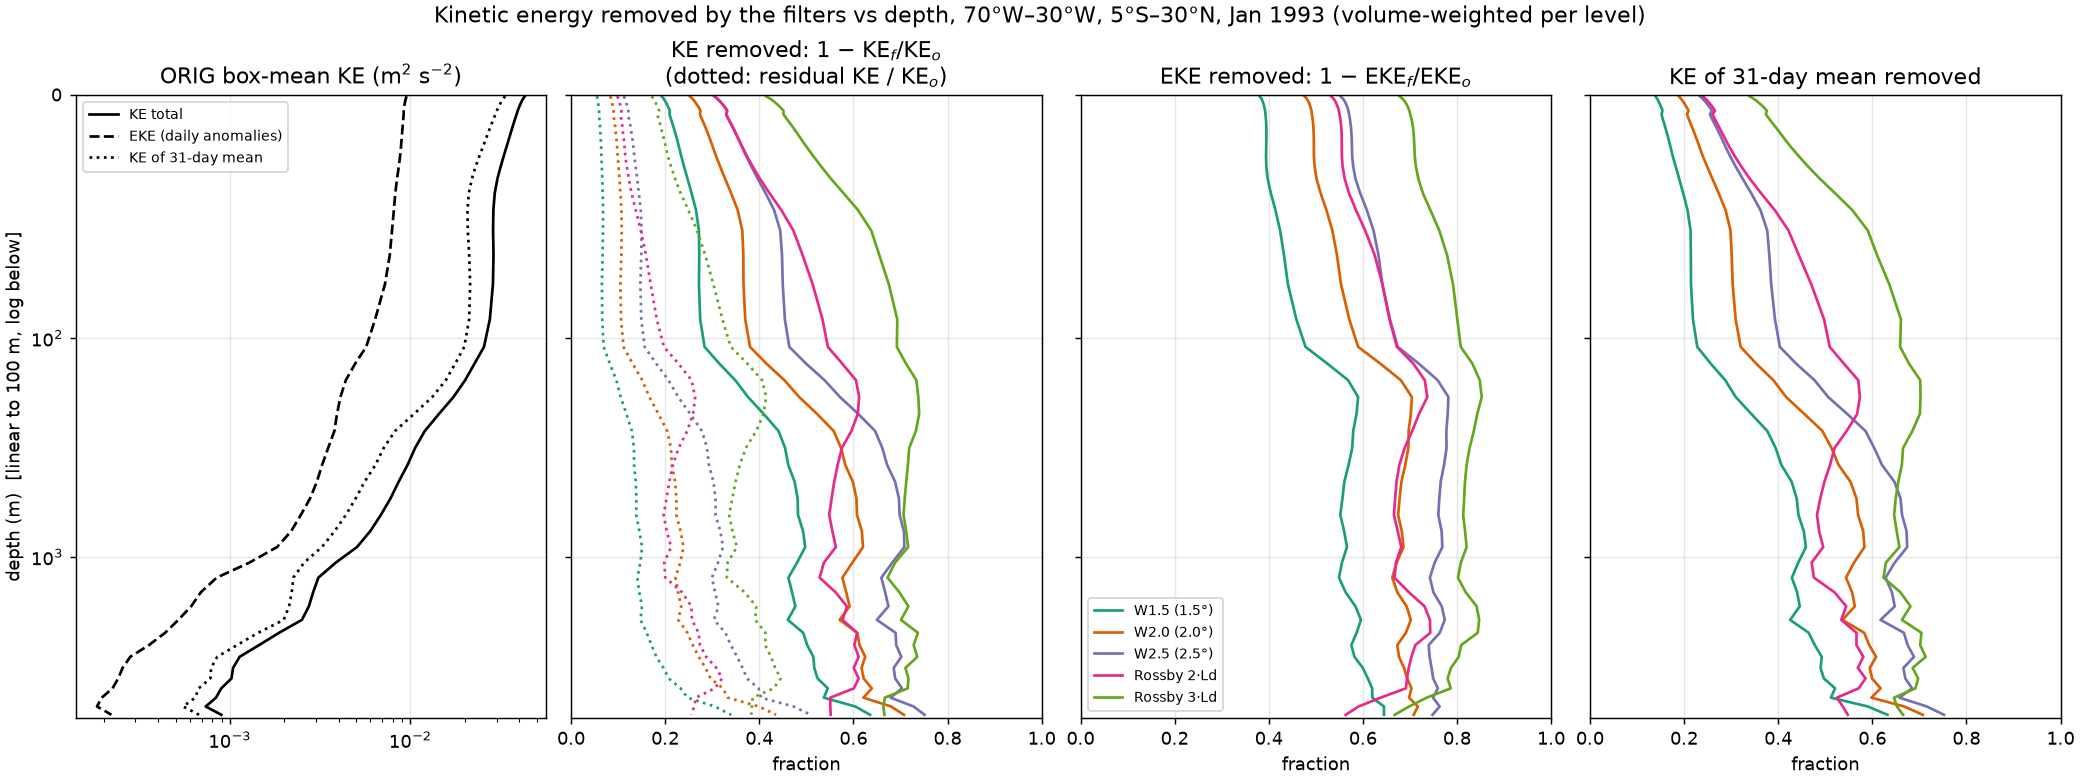

In [8]:
# energy removed vs depth, all 50 levels (figure from the full analysis, analysis/nbc_energy)
from IPython.display import Image, display
display(Image(RUN + '/analysis/nbc_energy/fig_energy_profiles.png', width=1100))

## 7. Spectra: the energy removed as a function of wavelength

These are KE wavenumber spectra of U,V from the full analysis (31-day mean of daily spectra, Hann window) in two land-free boxes:
- **STA:** subtropical, 55–35°W, 18–28°N, eddy-rich
- **WTA:** western tropical Atlantic, 50–35°W, 5–14°N, the NBC ring corridor

The shaded area between the original and filtered spectra is the energy each filter removes. The lower panels compare the measured ratio filtered/original with the theoretical $G^2$.

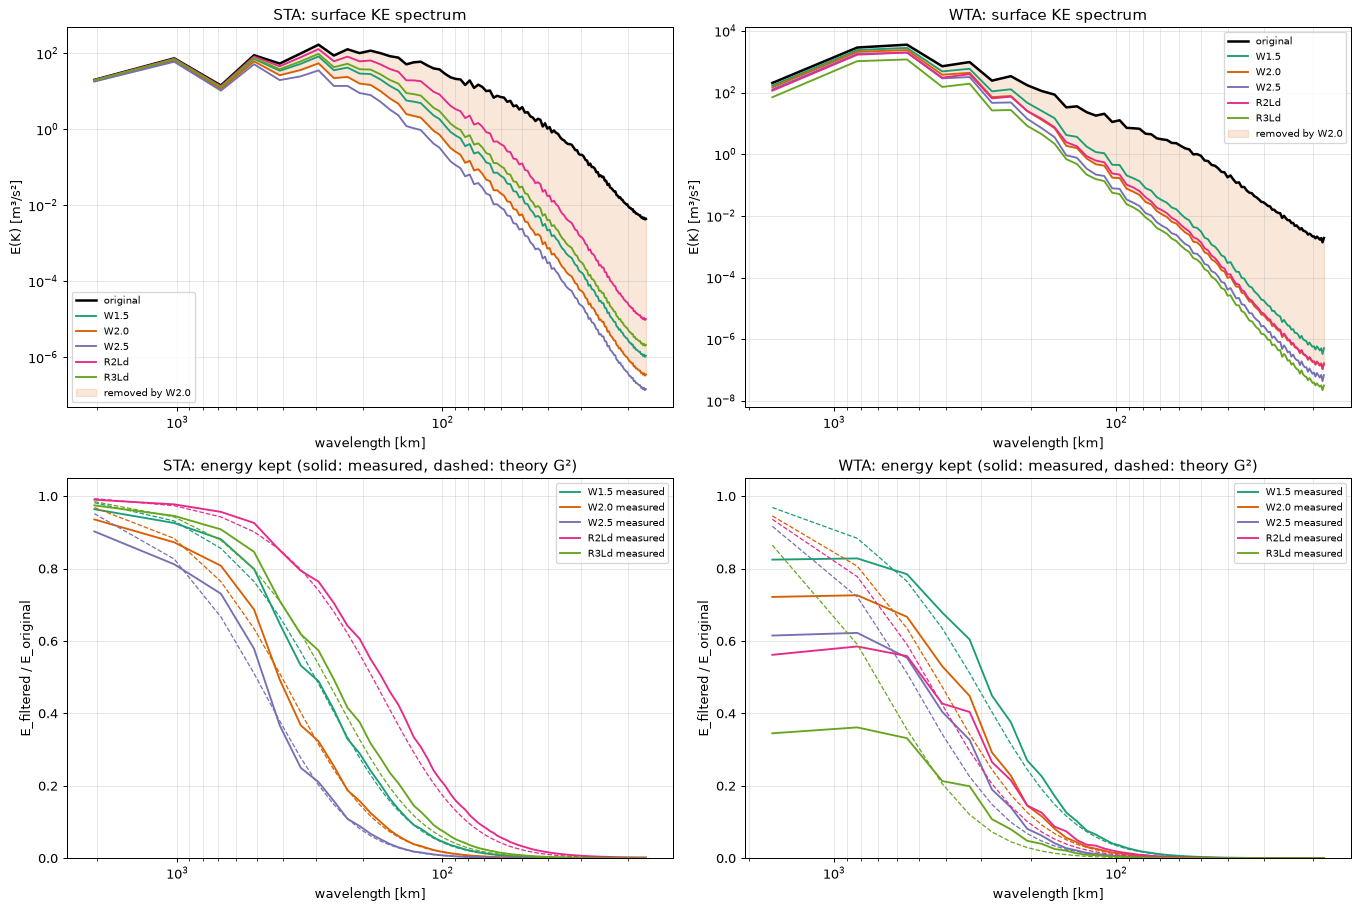

In [9]:
S = np.load(RUN + '/analysis/spectra_divergence/spectra_hann.npz')
fig, ax = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
for col, bx in enumerate(['STA', 'WTA']):
    K = S[f'{bx}_K']; lamk = 2 * np.pi / K / 1e3
    a = ax[0, col]
    a.loglog(lamk, S[f'{bx}_0_ORIG_E'], 'k', lw=2, label='original')
    for c in CFGS:
        a.loglog(lamk, S[f'{bx}_0_{c}_E'], color=COL[c], label=c)
    a.fill_between(lamk, S[f'{bx}_0_W2.0_E'], S[f'{bx}_0_ORIG_E'], color=COL['W2.0'], alpha=.15, label='removed by W2.0')
    a.invert_xaxis(); a.set_xlabel('wavelength [km]'); a.set_ylabel('E(K) [m³/s²]'); a.grid(alpha=.3, which='both')
    a.set_title(f'{bx}: surface KE spectrum'); a.legend(fontsize=8)
    a = ax[1, col]
    for c in CFGS:
        a.semilogx(lamk, S[f'{bx}_0_{c}_T'], color=COL[c], label=f'{c} measured')
        a.semilogx(lamk, S[f'{bx}_0_{c}_Tth'], '--', color=COL[c], lw=1)
    a.invert_xaxis(); a.set_ylim(0, 1.05); a.set_xlabel('wavelength [km]'); a.set_ylabel('E_filtered / E_original')
    a.set_title(f'{bx}: energy kept (solid: measured, dashed: theory G²)'); a.grid(alpha=.3, which='both'); a.legend(fontsize=8)

## 8. NBC rings in time: Hovmöller along 8°N

This is the meridional velocity v at the surface along 8°N (65–40°W) over January 1993. NBC rings shed at the retroflection (~50°W) drift north-westward and show up as alternating-sign bands moving west.
- The **removed** panels show the part of the ring signal each filter takes out.
- The **filtered** panels show what a Lagrangian particle would still feel.

Text(0.5, 0.98, 'Surface meridional velocity along 8°N')

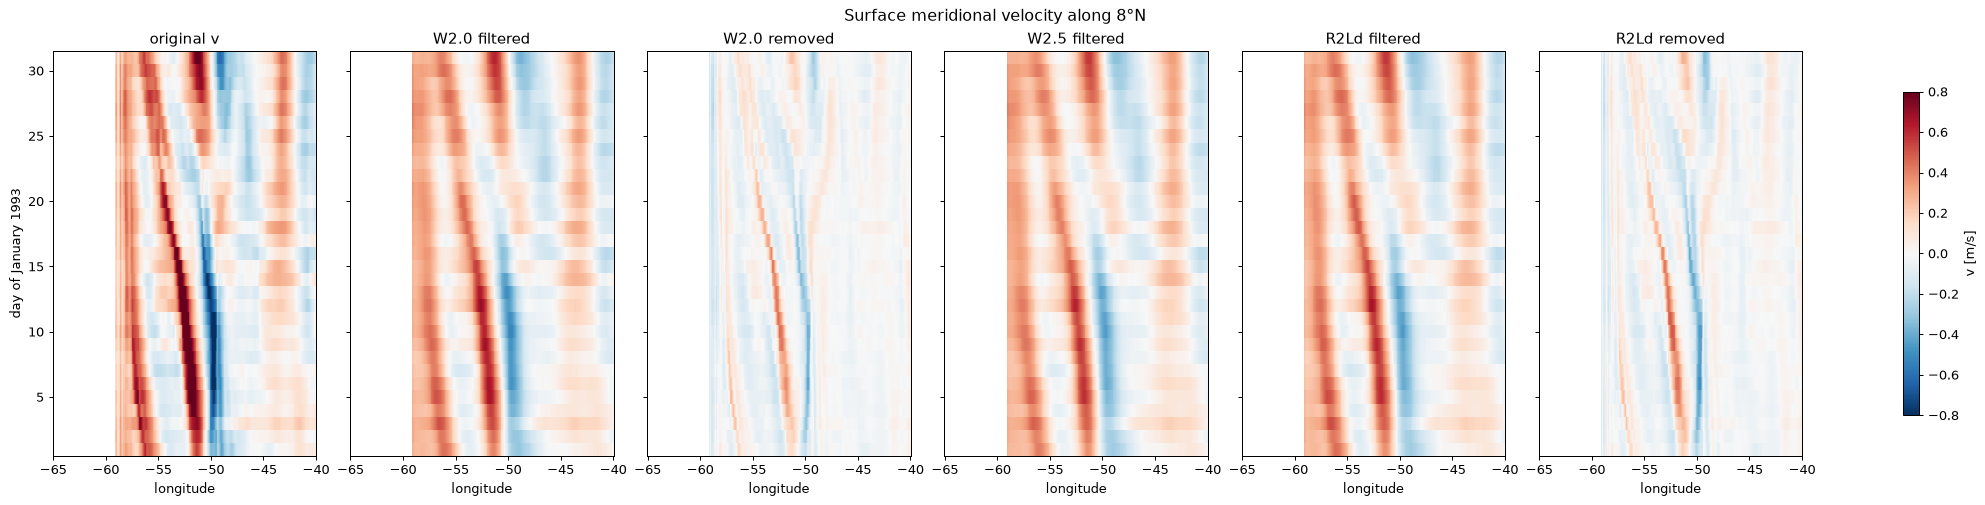

In [10]:
jh = np.argmin(abs(lat[:, 700] - 8.0)); ih = box(-65, -40, 0, 20)[1]
vh = {c: netCDF4.Dataset(path('V', c))['vomecrty'][:, 0, jh, ih].filled(np.nan) for c in ['ORIG', 'W2.0', 'W2.5', 'R2Ld']}
days = np.arange(1, 32); lonh = lon[jh, ih]
fig, ax = plt.subplots(1, 6, figsize=(22, 5.5), sharey=True, constrained_layout=True)
panels = [('ORIG', vh['ORIG'], 'original v'), ('W2.0', vh['W2.0'], 'W2.0 filtered'), ('W2.0 removed', vh['ORIG'] - vh['W2.0'], 'W2.0 removed'),
          ('W2.5', vh['W2.5'], 'W2.5 filtered'), ('R2Ld', vh['R2Ld'], 'R2Ld filtered'), ('R2Ld removed', vh['ORIG'] - vh['R2Ld'], 'R2Ld removed')]
for a, (_, f, ttl) in zip(ax, panels):
    pc = a.pcolormesh(lonh, days, f, vmin=-0.8, vmax=0.8, cmap='RdBu_r'); a.set_title(ttl); a.set_xlabel('longitude')
ax[0].set_ylabel('day of January 1993'); fig.colorbar(pc, ax=ax, shrink=.8, label='v [m/s]')
fig.suptitle('Surface meridional velocity along 8°N', fontsize=13)

## 9. The North Brazil Current at 44°W: original, filtered, removed

This is the January-mean zonal velocity (u < 0 = westward NBC) in a section from the Brazilian coast to 6°N at 44°W, 0–1000 m. The removed part shows how much of the narrow slope jet each filter spreads out.

ORIG: all westward flow 0–1000 m, coast–6°N at 44°W (NBC + South Equatorial Current) = 67.7 Sv
W2.0: all westward flow 0–1000 m, coast–6°N at 44°W (NBC + South Equatorial Current) = 56.7 Sv
R2Ld: all westward flow 0–1000 m, coast–6°N at 44°W (NBC + South Equatorial Current) = 43.3 Sv
(the report quotes the NBC-only transport in the fixed NBC region: ORIG 36.0 Sv, W2.0 30.3 Sv, R2Ld 22.9 Sv)


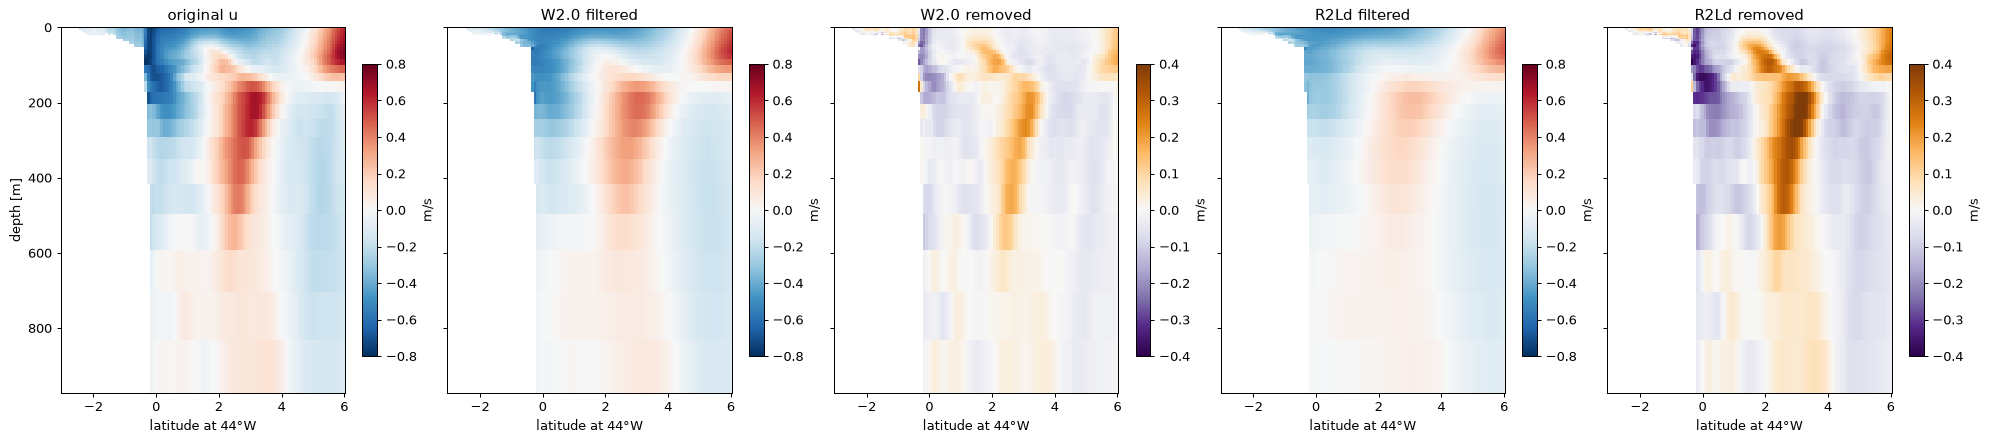

In [11]:
js44 = box(-44.2, -43.9, -3, 6.05)[0]
i44 = np.argmin(abs(mesh.glamu[200] + 44.04))
z = mesh.gdept_0; kz = np.where(z < 1000)[0]
us = {c: netCDF4.Dataset(path('U', c))['vozocrtx'][:, kz, js44, i44].filled(np.nan).mean(0) for c in ['ORIG', 'W2.0', 'R2Ld']}
latsec = mesh.gphiu[js44, i44]
fig, ax = plt.subplots(1, 5, figsize=(22, 4.8), sharey=True, constrained_layout=True)
for a, (f, ttl, cm, vm) in zip(ax, [(us['ORIG'], 'original u', 'RdBu_r', .8), (us['W2.0'], 'W2.0 filtered', 'RdBu_r', .8),
                                   (us['ORIG'] - us['W2.0'], 'W2.0 removed', 'PuOr_r', .4), (us['R2Ld'], 'R2Ld filtered', 'RdBu_r', .8),
                                   (us['ORIG'] - us['R2Ld'], 'R2Ld removed', 'PuOr_r', .4)]):
    pc = a.pcolormesh(latsec, z[kz], f, vmin=-vm, vmax=vm, cmap=cm); a.set_title(ttl); a.set_xlabel('latitude at 44°W')
    fig.colorbar(pc, ax=a, shrink=.8, label='m/s')
ax[0].invert_yaxis(); ax[0].set_ylabel('depth [m]')
e2u = mesh.e2u[js44, i44]; e3u = mesh.e3u[kz][:, js44, i44]
for c in us:
    tr = -np.nansum(np.where(us[c] < 0, us[c], 0) * e2u[None] * e3u) / 1e6
    print(f'{c}: all westward flow 0–1000 m, coast–6°N at 44°W (NBC + South Equatorial Current) = {tr:.1f} Sv')
print('(the report quotes the NBC-only transport in the fixed NBC region: ORIG 36.0 Sv, W2.0 30.3 Sv, R2Ld 22.9 Sv)')

## 10. Summary and recommendation

Numbers from the full analysis (`implicit_run/REPORT.md`), box 70–30°W 5°S–30°N, January 1993:

| | W1.5 | **W2.0** | W2.5 | R2Ld | R3Ld |
|---|---|---|---|---|---|
| box width at 0° / 15°N / 30°N [km] | 167 / 161 / 145 | **222 / 215 / 193** | 278 / 269 / 241 | 474 / 144 / 66 | 711 / 217 / 99 |
| EKE removed (0–1000 m) | 53 % | **64 %** | 73 % | 66 % | 81 % |
| total KE removed (0–1000 m) | 38 % | **49 %** | 57 % | 53 % | 68 % |
| NBC transport change 44°W / 5°N | −11 / −11 % | **−16 / −15 %** | −21 / −19 % | −37 / −25 % | −49 / −35 % |
| NBC core speed change 44°W | −19 % | **−23 %** | −28 % | −34 % | −40 % |
| retroflection mean-pattern correlation | 0.99 | **0.99** | 0.98 | 0.98 | 0.95 |
| NBC-ring KE kept | ~78 % | **~68 %** | ~60 % | ~65 % | ~50 % |

### What R2Ld and R3Ld are, and why they are not recommended here
R2Ld and R3Ld set the filter width to **2 × and 3 × the local first-baroclinic Rossby radius** $L_d$, the natural eddy scale.
- **Near the equator** $L_d$ ≈ 240 km, so the filter is 470–710 km wide. It cuts into the **North Brazil Current and the equatorial currents**: the NBC loses 37–49 % of its transport.
- **North of ~15°N** $L_d$ is only 30–60 km, so the filter is 70–150 km wide and **leaves most subtropical eddies in place** (sections 5–6).

For "remove the mesoscale, keep the large-scale circulation" in the Amazon/NBC region this is the wrong way round. The Rossby filters are also less clean numerically: continuity errors are ~10× those of the windows where $L_d$ changes fast.

### Recommended window: **W2.0** (2° window, $\ell = 2°\cdot\frac{\pi}{180}R\cos\varphi/3.5$ ≈ 63 km, box ≈ 222 km)
- **Removes two thirds of the eddy energy** and essentially all eddies and filaments smaller than ~100–150 km (sections 4–7).
- **Keeps the NBC → retroflection → NECC pathway**, which carries Amazon water (r = 0.99; NBC transport −16 %), and the >10° circulation (1.5 % difference at the surface).
- **Beyond 2°:** W2.5 removes 9 % more EKE but costs another ~5 % of NBC transport and more of the mean currents. W1.5 leaves half of the eddy energy in place.
- **For Lagrangian tracking:** filtered U, V, W stay kinematically consistent, and there is no flow through coasts.

**Caveats.**
- **Rings:** NBC rings (300–450 km) are weakened (~2/3 of their KE kept) but not removed by any configuration. Removing them would also destroy the NBC with this n = 1 filter; a steeper n = 2 filter would be the next thing to test.
- **Coast:** speeds within ~45 km of the coast come out 13–29 % higher.
- **Northern edge:** keep particles ≥ 1.7° from the 30°N edge of the extracted domain.
- **Seasons:** check a few other months (spring/autumn) before processing the full dataset.